# Decision Tree and Random Forest on the Wine Dataset

This notebook demonstrates tree-based classification models implemented in the `jiayi_ml` package:

- `DecisionTreeClassifier`
- `RandomForestClassifier`

The goal is to classify wine samples into one of three cultivars based on chemical measurements.

This example emphasizes:

1. Multiclass classification.
2. Decision tree interpretability.
3. Overfitting in single trees.
4. Ensemble stability in random forests.
5. Feature importance analysis.
6. Confusion matrix interpretation.


## 1. Problem Statement

The Wine dataset is a supervised multiclass classification dataset.

Each observation is a wine sample described by chemical measurements. The target label represents the wine cultivar.

The prediction task is:

> Given chemical measurements of a wine sample, predict its cultivar class.

This notebook compares two tree-based approaches:

- A single decision tree, which is easy to interpret but can overfit.
- A random forest, which averages many trees to improve stability and generalization.

The main modeling question is:

> Does the ensemble model improve generalization compared with a single decision tree?


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import DecisionTreeClassifier, RandomForestClassifier
from jiayi_ml.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Load the Dataset

The Wine dataset is loaded from `sklearn.datasets.load_wine`, so this notebook is reproducible without external downloads.

The dataset contains 13 chemical measurements, including alcohol, malic acid, ash, alkalinity of ash, magnesium, phenols, flavanoids, color intensity, hue, and proline.

The target has three classes, corresponding to three wine cultivars.


In [2]:
wine = load_wine(as_frame=True)

X = wine.data
y = wine.target
feature_names = X.columns.tolist()
target_names = wine.target_names

df = X.copy()
df["class"] = y
df["class_name"] = df["class"].map(lambda idx: target_names[idx])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_names))
print("Target names:", target_names)

df.head()


Feature matrix shape: (178, 13)
Target shape: (178,)
Number of features: 13
Target names: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 3. Exploratory Data Analysis

Before modeling, we inspect missing values, feature summaries, and class balance.

Class balance matters because a model can achieve misleadingly high accuracy if one class dominates the dataset. Here, the three classes are not exactly equal but all are represented.


In [3]:
missing_values = df.isna().sum()

print("Total missing values:", int(missing_values.sum()))

summary = X.describe().T
summary


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.0006,0.8118,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.3363,1.1171,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.3665,0.2743,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.4949,3.3396,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.7416,14.2825,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.2951,0.6259,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.0293,0.9989,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.3619,0.1245,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.5909,0.5724,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.0581,2.3183,1.28,3.2200,4.690,6.2000,13.00


In [4]:
class_counts = df["class_name"].value_counts().reindex(target_names)

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
class_name,,
class_0,59,0.3315
class_1,71,0.3989
class_2,48,0.2697


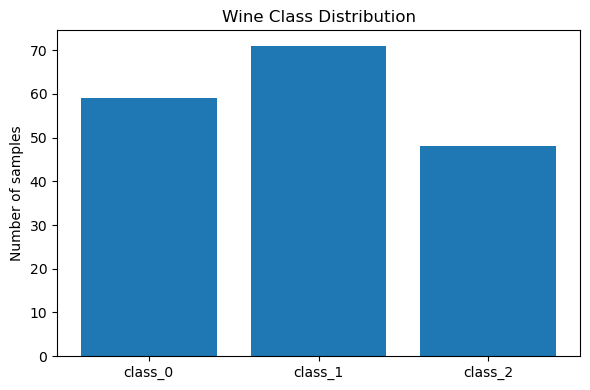

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts_df.index, class_counts_df["count"])
plt.ylabel("Number of samples")
plt.title("Wine Class Distribution")
plt.tight_layout()
plt.show()


## 4. Feature Exploration

Tree-based models can handle features with different scales because splits are based on thresholds. However, exploratory plots are still useful for understanding which features may help separate classes.

The following plots show the distributions of several chemical measurements by class.


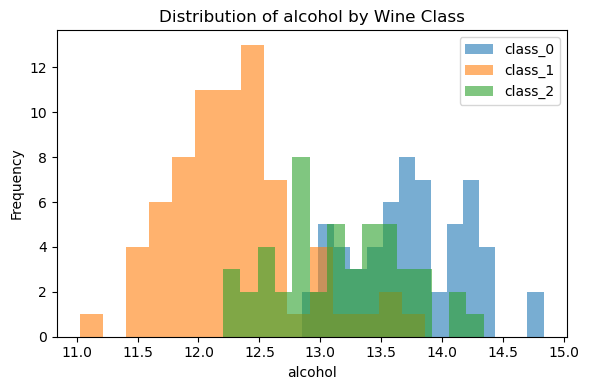

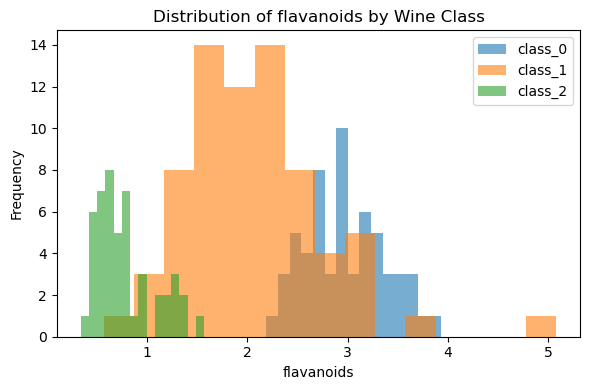

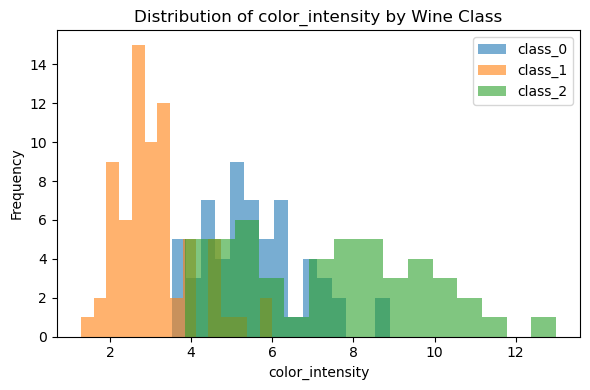

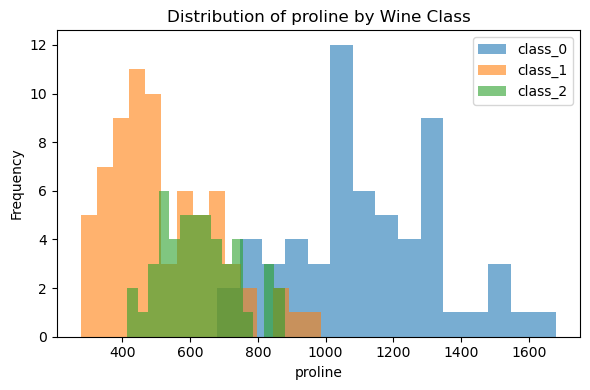

In [6]:
selected_features = [
    "alcohol",
    "flavanoids",
    "color_intensity",
    "proline",
]

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    for class_idx, class_name in enumerate(target_names):
        plt.hist(
            X.loc[y == class_idx, feature],
            bins=15,
            alpha=0.6,
            label=class_name,
        )
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature} by Wine Class")
    plt.legend()
    plt.tight_layout()
    plt.show()


Some features show clear separation between classes, while others overlap. This motivates tree-based models because trees can create nonlinear decision rules through feature thresholds.

Unlike logistic regression, a decision tree does not require a single global linear boundary.


## 5. Train/Test Split

The data is split into training and test sets using stratification to preserve class proportions.

Although tree-based models do not require standardization, this notebook still creates a standardized version of the data for consistency with other examples. The tree models below use the original feature values so that thresholds and feature importances remain easier to interpret.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=438,
    stratify=y.values,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training set shape: (133, 13)
Test set shape: (45, 13)
Training class counts: [44 53 36]
Test class counts: [15 18 12]


## 6. Fit Decision Tree and Random Forest Models

We fit three models:

1. A shallow decision tree.
2. A deeper decision tree.
3. A random forest.

The shallow tree is more constrained and easier to interpret. The deeper tree is more flexible and may overfit. The random forest averages multiple trees trained on bootstrap samples, which often improves stability.


In [8]:
models = {
    "Decision Tree, max_depth=3": DecisionTreeClassifier(
        max_depth=3,
        criterion="gini",
        random_state=438,
    ),
    "Decision Tree, unrestricted": DecisionTreeClassifier(
        max_depth=None,
        criterion="gini",
        random_state=438,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=None,
        criterion="gini",
        max_features="sqrt",
        bootstrap=True,
        random_state=438,
    ),
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} fitted.")


Decision Tree, max_depth=3 fitted.
Decision Tree, unrestricted fitted.


Random Forest fitted.


## 7. Test-Set Evaluation

For multiclass classification, we evaluate:

- Accuracy
- Macro precision
- Macro recall
- Macro F1 score

Macro averaging computes the metric separately for each class and then averages across classes. This treats all classes equally.


In [9]:
def macro_metric(metric_function, y_true, y_pred, labels):
    values = []
    for label in labels:
        values.append(metric_function(y_true, y_pred, pos_label=label))
    return float(np.mean(values))


labels = np.array([0, 1, 2])
results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_precision": macro_metric(precision_score, y_test, y_pred, labels),
            "macro_recall": macro_metric(recall_score, y_test, y_pred, labels),
            "macro_f1": macro_metric(f1_score, y_test, y_pred, labels),
        }
    )

results_df = pd.DataFrame(results).set_index("model")
results_df


,accuracy,macro_precision,macro_recall,macro_f1
model,,,,
"Decision Tree, max_depth=3",0.8889,0.9108,0.8704,0.8774
"Decision Tree, unrestricted",0.8889,0.9094,0.8704,0.8760
Random Forest,0.9778,0.9744,0.9815,0.9771


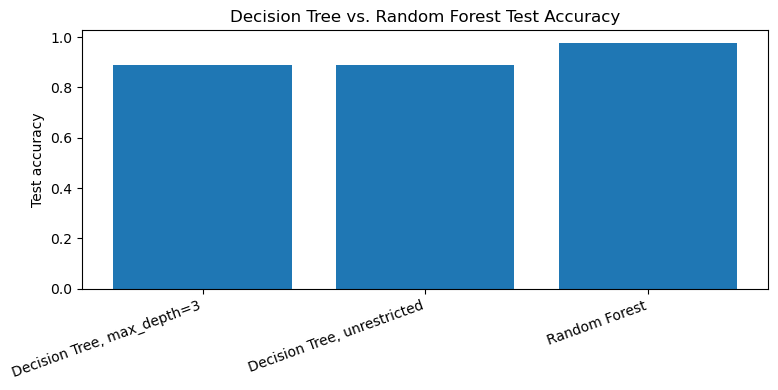

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(results_df.index, results_df["accuracy"])
plt.ylabel("Test accuracy")
plt.title("Decision Tree vs. Random Forest Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


A single unrestricted tree can fit complex patterns but may be unstable because small changes in the training data can produce different splits. A random forest reduces this instability by averaging predictions across many trees.

The test-set metrics allow us to compare whether the ensemble improves generalization relative to a single tree.


## 8. Confusion Matrices

Confusion matrices show which wine classes are confused by each model.

This is important because two models may have similar accuracy but make different types of mistakes.


Decision Tree, max_depth=3


,predicted class_0,predicted class_1,predicted class_2
true class_0,15,0,0
true class_1,1,17,0
true class_2,1,3,8


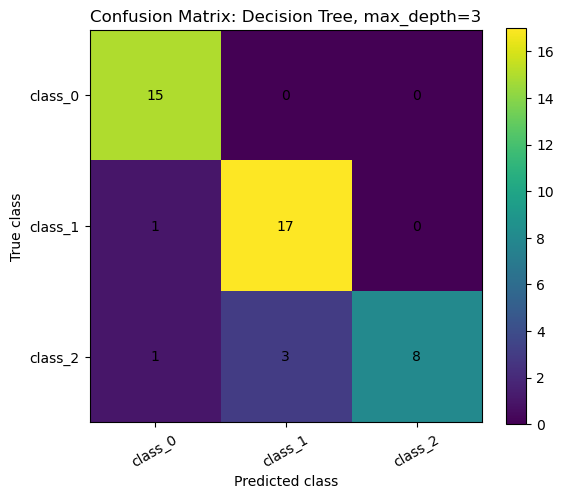

Decision Tree, unrestricted


,predicted class_0,predicted class_1,predicted class_2
true class_0,15,0,0
true class_1,1,17,0
true class_2,2,2,8


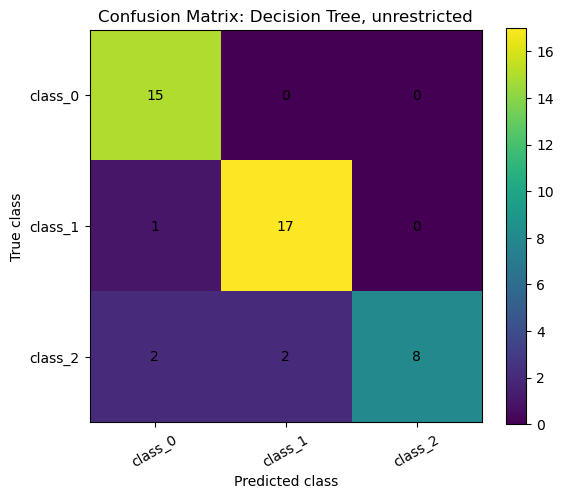

Random Forest


,predicted class_0,predicted class_1,predicted class_2
true class_0,15,0,0
true class_1,0,17,1
true class_2,0,0,12


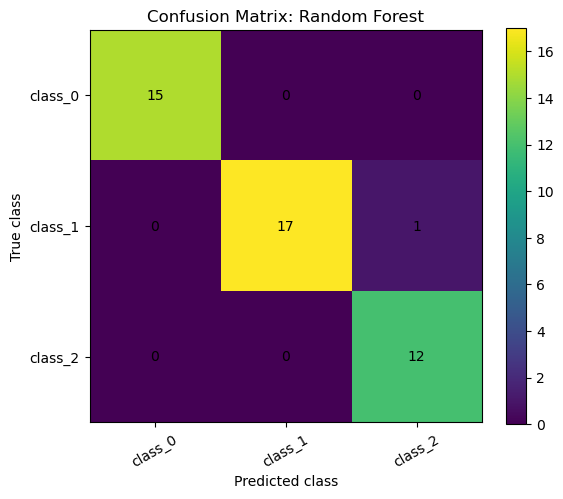

In [11]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    
    cm_df = pd.DataFrame(
        cm,
        index=[f"true {name}" for name in target_names],
        columns=[f"predicted {name}" for name in target_names],
    )
    
    print(model_name)
    display(cm_df)
    
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.xticks([0, 1, 2], target_names, rotation=30)
    plt.yticks([0, 1, 2], target_names)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


The confusion matrices identify class-specific errors. If most mistakes occur between two particular cultivars, that suggests those classes have overlapping chemical profiles in the selected feature space.


## 9. Feature Importance

Both the custom decision tree and random forest implementations compute feature importances based on impurity reduction.

Feature importance answers:

> Which features were most useful for splitting the data?

For a single tree, importance can be unstable because it depends on one fitted tree structure. For a random forest, feature importance is averaged across many trees and is usually more stable.


In [12]:
importance_frames = []

for model_name, model in models.items():
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": model.feature_importances_,
            "model": model_name,
        }
    ).sort_values("importance", ascending=False)
    
    importance_frames.append(importance_df)
    
    print(model_name)
    display(importance_df.head(8))


Decision Tree, max_depth=3


,feature,importance,model
12,proline,0.4057,"Decision Tree, max_depth=3"
9,color_intensity,0.3358,"Decision Tree, max_depth=3"
6,flavanoids,0.1286,"Decision Tree, max_depth=3"
5,total_phenols,0.0664,"Decision Tree, max_depth=3"
4,magnesium,0.0456,"Decision Tree, max_depth=3"
1,malic_acid,0.0179,"Decision Tree, max_depth=3"
0,alcohol,0.0000,"Decision Tree, max_depth=3"
2,ash,0.0000,"Decision Tree, max_depth=3"


Decision Tree, unrestricted


,feature,importance,model
12,proline,0.3879,"Decision Tree, unrestricted"
9,color_intensity,0.3421,"Decision Tree, unrestricted"
6,flavanoids,0.1230,"Decision Tree, unrestricted"
5,total_phenols,0.0634,"Decision Tree, unrestricted"
4,magnesium,0.0436,"Decision Tree, unrestricted"
0,alcohol,0.0228,"Decision Tree, unrestricted"
1,malic_acid,0.0171,"Decision Tree, unrestricted"
2,ash,0.0000,"Decision Tree, unrestricted"


Random Forest


,feature,importance,model
12,proline,0.1802,Random Forest
0,alcohol,0.1563,Random Forest
11,od280/od315_of_diluted_wines,0.1548,Random Forest
9,color_intensity,0.1515,Random Forest
6,flavanoids,0.1076,Random Forest
10,hue,0.0700,Random Forest
5,total_phenols,0.0484,Random Forest
3,alcalinity_of_ash,0.0331,Random Forest


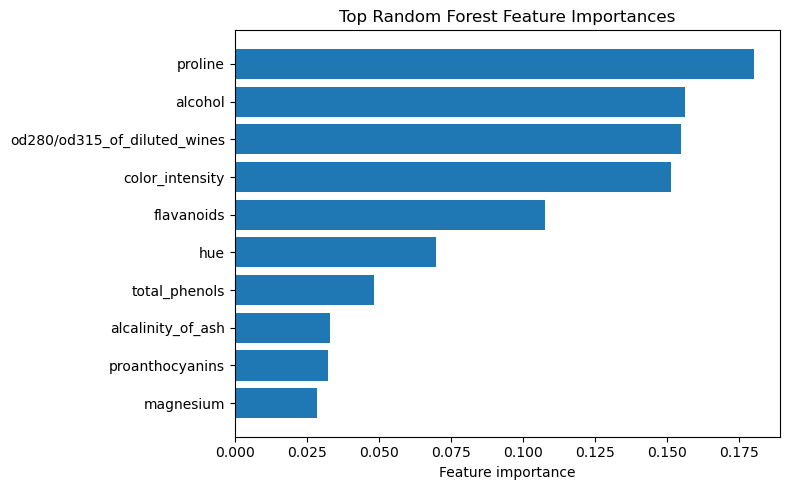

In [13]:
forest_importance = importance_frames[-1].head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(forest_importance["feature"], forest_importance["importance"])
plt.xlabel("Feature importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()


Feature importance can help interpret which chemical measurements drive the model. However, it should be interpreted carefully:

- Correlated features can share or distort importance.
- Importance does not imply causality.
- A feature can be useful for prediction without being independently meaningful.


## 10. Train vs. Test Performance

Overfitting can be assessed by comparing training and test performance.

A model with much higher training accuracy than test accuracy may be fitting noise or idiosyncrasies in the training set.


In [14]:
train_test_comparison = []

for model_name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_test_comparison.append(
        {
            "model": model_name,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        }
    )

train_test_df = pd.DataFrame(train_test_comparison).set_index("model")
train_test_df


,train_accuracy,test_accuracy,gap
model,,,
"Decision Tree, max_depth=3",0.985,0.8889,0.0961
"Decision Tree, unrestricted",1.000,0.8889,0.1111
Random Forest,1.000,0.9778,0.0222


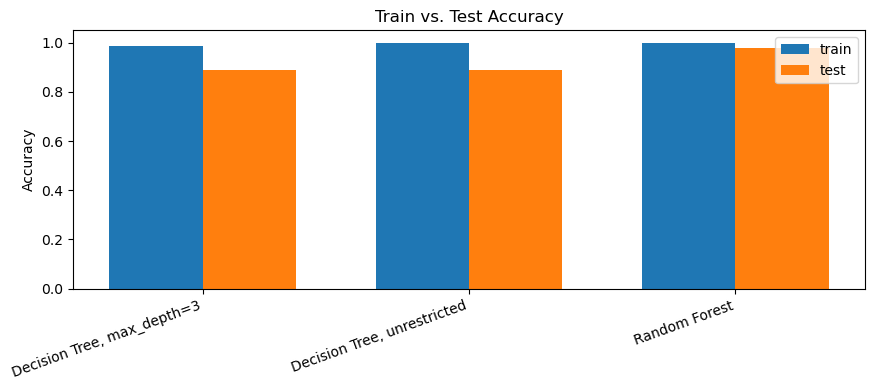

In [15]:
x = np.arange(len(train_test_df.index))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width / 2, train_test_df["train_accuracy"], width, label="train")
plt.bar(x + width / 2, train_test_df["test_accuracy"], width, label="test")
plt.xticks(x, train_test_df.index, rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


The train-test comparison illustrates the bias-variance trade-off.

A shallow tree may underfit but is more constrained. An unrestricted tree can fit training data very well but may generalize less reliably. A random forest often improves generalization by averaging multiple high-variance trees.


## 11. Interpretation

The decision tree provides a transparent model structure based on threshold splits. This makes it useful for explanation, but it can be sensitive to small changes in the data.

The random forest sacrifices some interpretability at the individual-tree level but often improves predictive stability. Its feature importance values provide a summary of which variables were repeatedly useful across trees.

For the Wine dataset, tree-based models are appropriate because the classes can be separated using threshold-based rules on chemical measurements.


## 12. Limitations

This analysis has several limitations:

1. The dataset is small.
2. The test set is also small, so performance estimates may vary with the split.
3. Hyperparameters were chosen for demonstration rather than tuned by cross-validation.
4. Feature importance is not causal importance.
5. A random forest is less directly interpretable than a single decision tree.
6. The custom implementation is educational and does not include all optimizations in production libraries.

A stronger analysis could include cross-validation, hyperparameter tuning, repeated train/test splits, and comparison with additional classifiers.


## 13. Conclusion

This notebook demonstrated tree-based classification using custom implementations from `jiayi_ml`.

Key takeaways:

- Decision trees are interpretable but can overfit.
- Tree depth controls model complexity.
- Random forests improve stability by averaging many trees.
- Confusion matrices reveal class-specific mistakes.
- Feature importances summarize which variables were useful for splitting.
- Train/test comparison helps diagnose overfitting.
